# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [6]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [7]:
df.dtypes

season           int64
holiday          int64
workingday       int64
weather          int64
temp           float64
atemp          float64
humidity         int64
windspeed      float64
casual           int64
registered       int64
count            int64
date            object
day              int32
week            UInt32
weekday_num      int32
weekday         object
year             int32
month            int32
hour             int32
dtype: object

In [8]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


In [9]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day,week,weekday_num,year,month,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.0,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,9.992559,25.917784,3.013963,2011.501929,6.521495,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,5.476608,15.017269,2.004585,0.500019,3.444373,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,2011.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,5.000000,14.0,1.000000,2011.000000,4.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,10.000000,26.0,3.000000,2012.000000,7.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,15.000000,40.0,5.000000,2012.000000,10.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,19.000000,52.0,6.000000,2012.000000,12.000000,23.000000


Дані містять 10 886 рядків та 19 стовпчиків, практично всі стовпці містять цифрові дані (цілочисельні або з плаваючою комою), і лише 2 мають тип object (це date та weekday). Кожен рядок даних містить дані за 1 годину з 01.01.2011 до 19.12.2012, які фіксують погодні умови, кількість відвідувачів сайту та кількість орендованих велосипедів, точні дату та час в різних вимірах.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [10]:
daily_rents = df['count'].resample('D').sum()

In [11]:
daily_rents

datetime
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
              ... 
2012-12-15    5047
2012-12-16    3786
2012-12-17    4585
2012-12-18    5557
2012-12-19    5267
Freq: D, Name: count, Length: 719, dtype: int64

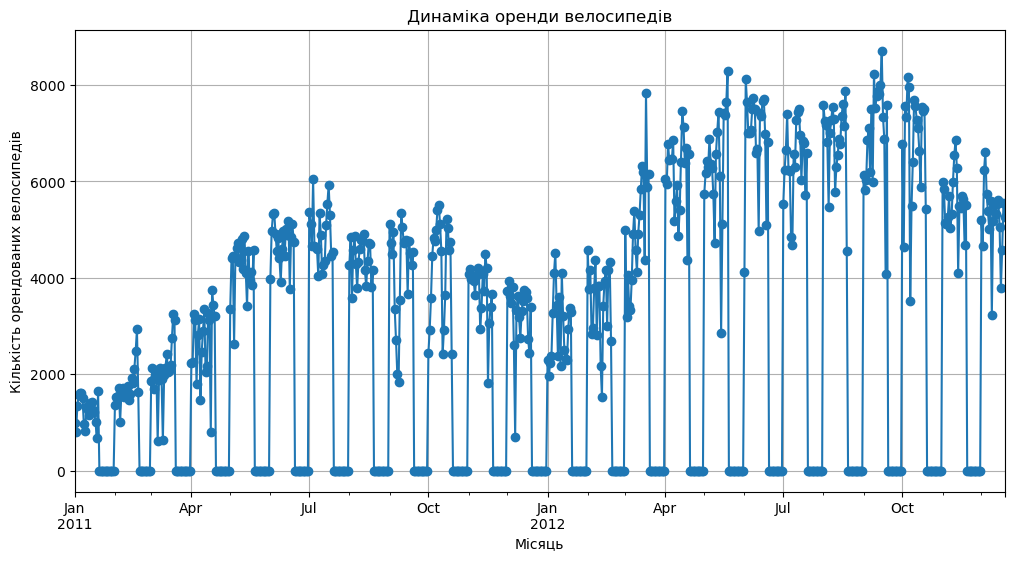

In [12]:
daily_rents.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Місяць',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);

1.Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
Оскільки графік отримав дані за день, то очевидно в деякі дні сервіс або не працював, або дані не були отримані. Для усунення нульових значень потрібно напевно відфільтрувати вхідні дані.

2.Які загальні тенденції ви бачите на графіку? Кількість оренди не рівномірна за місяцями року, найменші значення в січні-березень, найбільші - з травня до листопада. В 2012 році сервіс показав кращі результати за кількістю залучень, ніж в 2011.

3.Чи помітні якісь сезонні коливання? Так, чітко виражена сезонність: грудень-березень не є сезоном, інші місяці - суттєвий прирост показників.

4.Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії? Так, візуально можна спостерігати викиди: нульові значення є в кожному місяці (це орієнтовно з 20-го числа і до кінця кожного місяця відповідно), можливо сервіс не працює в цей період; за періоди з ненульовими даними є аномально низькі та високі точки, які можуть бути повʼязані із погодними умовами в той конкретний день або це могли бути вихідні чи святкові дні, без більш детального аналізу не можна зробити більш обгрунтований висновок.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [13]:
quater_rents = df['count'].resample('QE').mean()

In [14]:
[date.strftime('%d %b %Y') for date in quater_rents.index]

['31 Mar 2011',
 '30 Jun 2011',
 '30 Sep 2011',
 '31 Dec 2011',
 '31 Mar 2012',
 '30 Jun 2012',
 '30 Sep 2012',
 '31 Dec 2012']

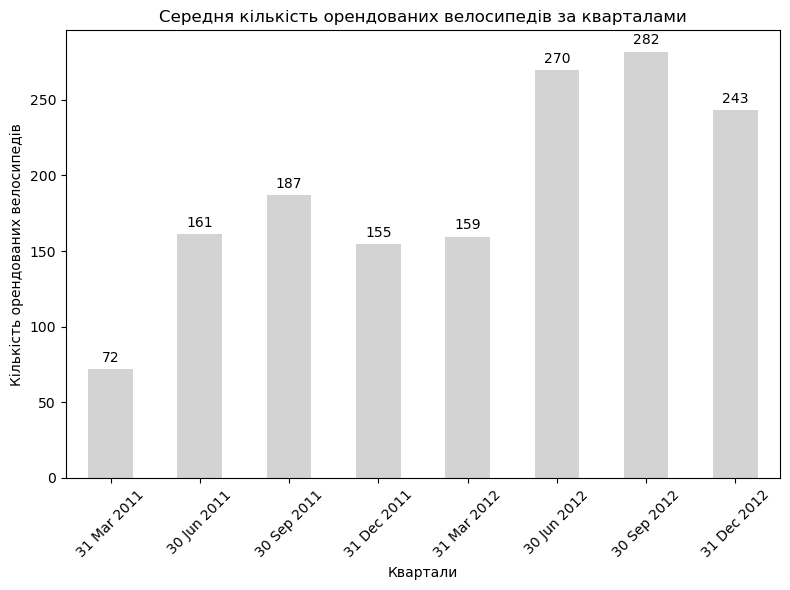

In [15]:
ax = quater_rents.plot.bar(
    figsize=(8, 6),
    color='lightgrey',
    title='Середня кількість орендованих велосипедів за кварталами',
    ylabel='Кількість орендованих велосипедів',
    xlabel='Квартали'
)

labels = [date.strftime('%d %b %Y') for date in quater_rents.index]
ax.set_xticklabels(labels)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f')

plt.xticks(rotation=45)
plt.tight_layout()

1.В який квартал найбільша середня кількість оренди велосипедів? Найбільша кількість припадає на 3й квартал, спостереження вірне як для 2011, так і для 2012 року.

2.Як ви можете пояснити таку сезонну закономірність? Можна припустити найкращі погодні умови для оренди велосипедів.

3.У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [16]:
k1 = quater_rents.max()
k2 = quater_rents.min()
k3 = k1 / k2
print(f'Max={k1:.2f}, Min={k2:.2f}, Difference = {k3:.2f}')

Max=281.74, Min=71.91, Difference = 3.92


Якщо розглянути весь період спостережень, то різниця між найпопулярнішим кварталом та найменш популярним складає 3,92 рази.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [17]:
df['date'] = pd.to_datetime(df['date'])

In [18]:
monthly = df.groupby(df['date'].dt.month)['count'].mean()

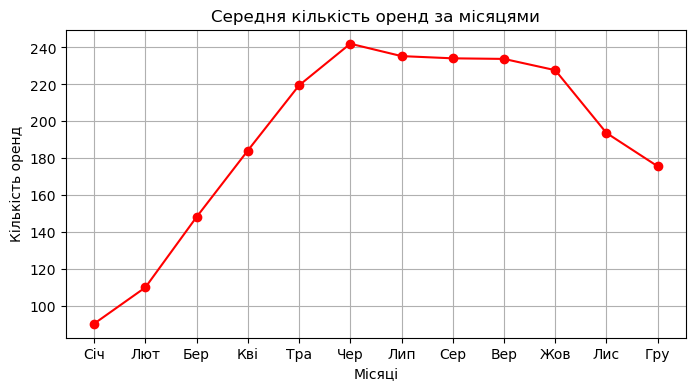

In [19]:
ax = monthly.plot.line(
    marker='o', 
    figsize=(8, 4),
    color='red',
    grid=True
)
ax.set_xlabel("Місяці")
ax.set_ylabel("Кількість оренд")
ax.set_title("Середня кількість оренд за місяцями")

ax.set_xticks(range(1, 13))
ax.set_xticklabels([
   "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
   "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]);

1.В які місяці спостерігається пік та спад оренди? Пік оренди припадає на червень, мінімум - на січень. Всі місяці з травня до жовтня мають значно більшу кількість оренд, ніж інші.

2.Чи збігається ця закономірність з результатами з попереднього завдання? В минулому завданні групування було за кварталами, тож результати не збігаються. Другий квартал має 1 максимальний місяць і 2 менші, а 3-й має всі три місяці з більшими значеннями. Тож, в розрізі середнього за кварталами першість у 3-го кварталу, а за місяцями - у 6-го місяця.

3.Як може вплинути клімат на оренду велосипедів протягом року? Суттєво, в теплий час року і без значних опадів кількість оренди зростає, оскільки погодні умови є одним з основним чинників комфортного та безпечного використання велосипеду.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [20]:
weather_count = df.groupby('weather')['season'].agg(["count"])

In [21]:
weather_count

,count
weather,
1,7192
2,2834
3,859
4,1


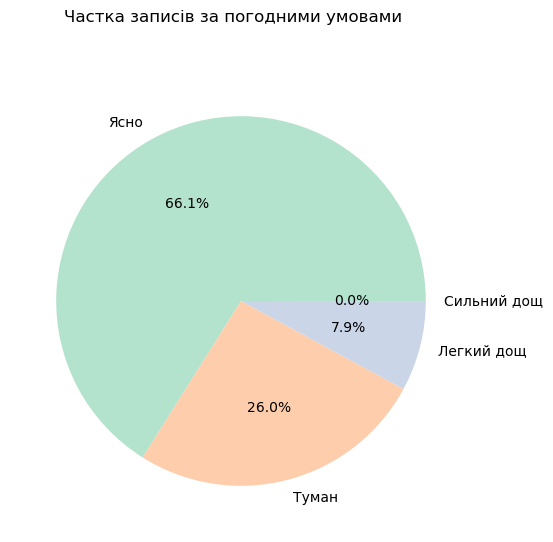

In [22]:
weather_count.plot.pie(
    subplots=True,
    figsize=(6, 6),
    autopct='%1.1f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    legend=False,
    colors=plt.cm.Pastel2.colors
);

1. Переважає ясна погода - 66%

2. Частка днів із сильним дощем 0%. Але за даними це 1 день.

3. Комфортні для перебування та пересування на вулиці погодні умови позитивно впливають на кількість оренди велосипедів, тому і переважає частка з ясною або туманною погодою.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

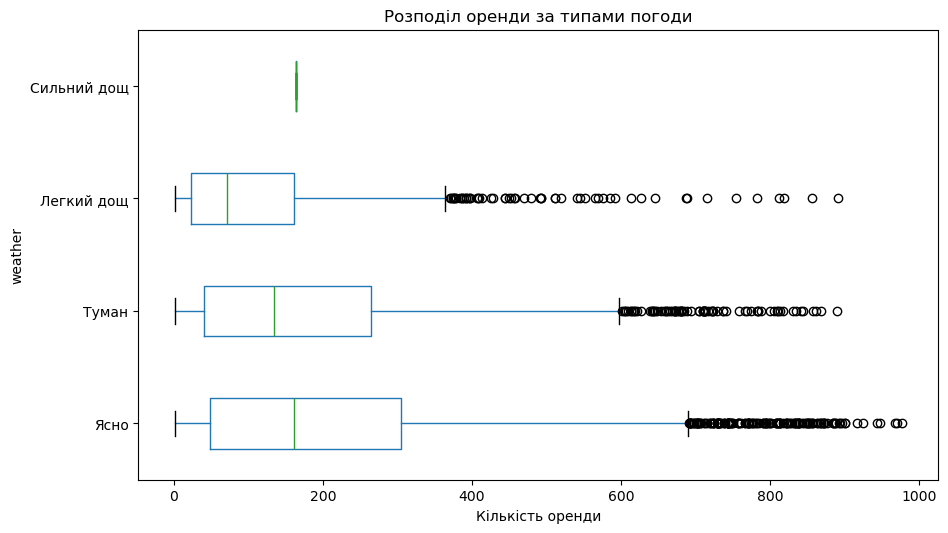

In [23]:
ax=df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    grid = False,
    vert=False
)
plt.title('Розподіл оренди за типами погоди')
plt.suptitle('')

ax.set_xlabel('Кількість оренди')
ax.set_yticklabels([
        "Ясно", "Туман", "Легкий дощ", "Сильний дощ"]
);

1. Найбільший розкид спостерігаємо при ясній погоді.

2. Викиди є в усіх типах погоди, окрім сильного дощу. Найбільші викиди при легкому дощі.

3. При ясній погоді медіанне значення вище. Близьким до нього є значення при сильному дощі, однак на нашу думку воно не є репрезентативним.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

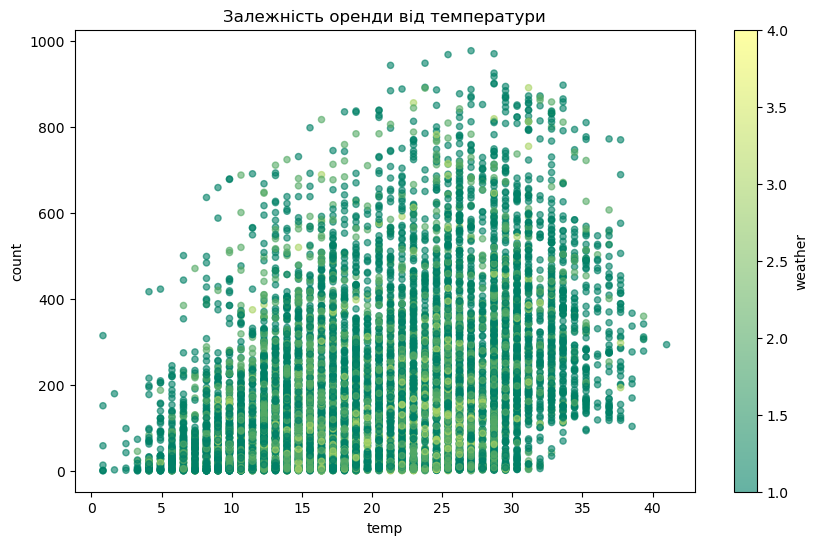

In [24]:
df.plot.scatter(
    x='temp',
    y='count',
    c='weather',
    colormap='summer',
    title='Залежність оренди від температури',
    figsize=(10, 6),
    alpha=0.6
)
plt.show()

Між температурою та кількістю оренди можна простежити позитивний звʼязок, однак краще було б згрупувати температуру за інтервалами, так звʼязок був би більш очевидним.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [98]:
weekday_labels = {
    0: "Пн",
    1: "Вт",
    2: "Ср",
    3: "Чт",
    4: "Пт",
    5: "Сб",
    6: "Нд"
}

df['weekday_name'] = df['weekday_num'].map(weekday_labels)

In [99]:
users = df[['casual', 'registered', 'count', 'weekday_name']]

In [100]:
users_mean = (
    df.groupby('weekday_name')[['casual', 'registered']]
      .mean()
)

In [101]:
order = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Нд"]

users_mean = users_mean.reindex(order)

In [102]:
users_mean['total'] = users_mean['casual'] + users_mean['registered']

In [103]:
users_mean

,casual,registered,total
weekday_name,,,
Пн,29.843972,160.546744,190.390716
Вт,22.979207,166.744639,189.723847
Ср,22.521599,165.889749,188.411348
Чт,24.007083,173.289118,197.296201
Пт,31.001962,166.842381,197.844343
Сб,63.625000,133.040404,196.665404
Нд,57.051298,123.788474,180.839772


In [104]:
shares = users_mean[['casual', 'registered']].div(
    users_mean[['casual', 'registered']].sum(axis=1),
    axis=0
)

In [105]:
shares

,casual,registered
weekday_name,,
Пн,0.156751,0.843249
Вт,0.121119,0.878881
Ср,0.119534,0.880466
Чт,0.121680,0.878320
Пт,0.156699,0.843301
Сб,0.323519,0.676481
Нд,0.315480,0.684520


In [106]:
shares_percent = shares * 100

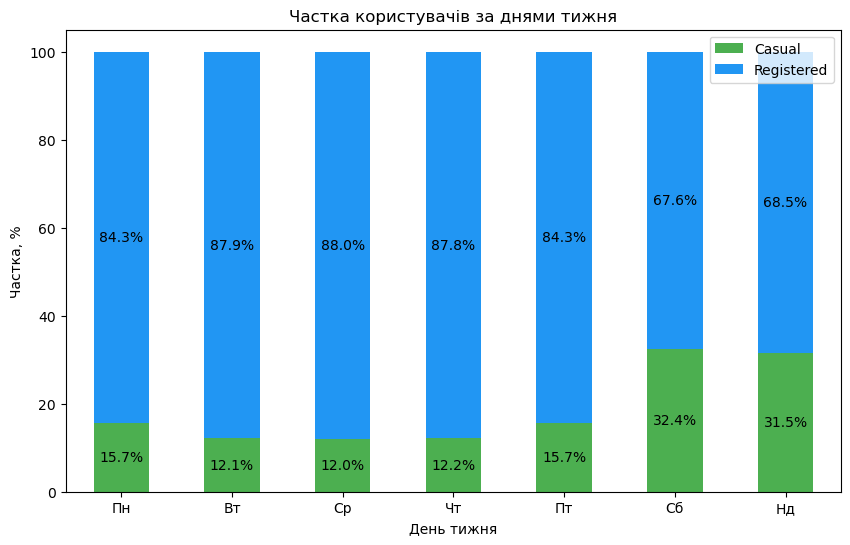

In [107]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = shares_percent.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#4CAF50', '#2196F3']
)

ax.set_title('Частка користувачів за днями тижня')
ax.set_ylabel('Частка, %')
ax.set_xlabel('День тижня')
ax.legend(['Casual', 'Registered'])
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

1.В які дні тижня більше оренд від зареєстрованих користувачів? Найбільша частка зареєстрованих користувачів припадає на робочі дні тижня ПН-ПТ.

2.Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня? Можемо припустити, що зареєстровані користувачі використовують орендований велосипед як засіб дістатися на роботу. А у вихідні дні частина зареєстрованих користувачів змінює свій розпорядок дня і не орендує велосипед, а випадкові користувачі навпаки, у свій неробочий день користуються орендою. 

In [108]:
users_mean_2 = (
    df.groupby('weekday_name')[['casual', 'registered']]
      .sum()
)

In [112]:
users_mean_2

,casual,registered
weekday_name,,
Вт,35365,256620
Нд,90084,195462
Пн,46288,249008
Пт,47402,255102
Сб,100782,210736
Ср,34931,257295
Чт,37283,269118


Як бачимо, в суботу та неділю суттєво виростає і абсолютне значення випадкових користувачів, і падає абсолютне значення зареєстрованих.